In [23]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Loading our attrition processed data into a pandas dataframe
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

# Visualizing top 5 records
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Exploratory Data Analysis
#### 1. Where is attrition concentrated?
- Which job roles, departments, and job levels exceed the 16.1% baseline, and by enough to matter given their headcount?
- Is attrition an early-tenure phenomenon, a mid-career phenomenon, or both?

In [25]:
# Checking the overall attrition rate in the dataset
attrition_rate = (df["Attrition"] == "Yes").mean()
print(f"Overall attrition rate: {attrition_rate:.1%}")

Overall attrition rate: 16.1%


In [26]:
# Defining our attrition rate baseline
BASELINE = attrition_rate

In [ ]:
# Creating a reusable attrition sumamry function for our analysis
def attrition_summary(df, column, baseline=BASELINE):
    summary = (
        df.groupby(column)
          .agg(
              Headcount=("EmployeeNumber", "size"),
              AttritionCount=("Attrition", lambda x: (x == "Yes").sum())
          )
    )

    # Calculate attrition rate as a percentage
    summary["AttritionRate"] = (
        summary["AttritionCount"] / summary["Headcount"] * 100
    )

    # Difference from company-wide baseline, in percentage points
    summary["DifferenceFromBaseline_pp"] = (
        summary["AttritionRate"] - (baseline * 100)
    )

    # How many times higher/lower than the baseline
    summary["RelativeToBaseline"] = (
        summary["AttritionRate"] / (baseline * 100)
    ).round(2)

    return summary.sort_values(
        "AttritionRate",
        ascending=False
    ).round(2)

In [28]:
# Checking attrition summary by JobRole
job_role_summary = attrition_summary(df, "JobRole")

job_role_summary

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
JobRole,,,,,
Sales Representative,83,33,39.76,23.64,2.47
Laboratory Technician,259,62,23.94,7.82,1.48
Human Resources,52,12,23.08,6.96,1.43
Sales Executive,326,57,17.48,1.36,1.08
Research Scientist,292,47,16.10,-0.02,1.00
Manufacturing Director,145,10,6.90,-9.22,0.43
Healthcare Representative,131,9,6.87,-9.25,0.43
Manager,102,5,4.90,-11.22,0.30
Research Director,80,2,2.50,-13.62,0.16


In [29]:
# Checking attrition summary by Department
department_summary = attrition_summary(df, "Department")

department_summary

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
Department,,,,,
Sales,446,92,20.63,4.51,1.28
Human Resources,63,12,19.05,2.93,1.18
Research & Development,961,133,13.84,-2.28,0.86


In [30]:
# Checking attrition summary by JobLevel
job_level_summary = attrition_summary(df, "JobLevel")

job_level_summary

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
JobLevel,,,,,
1,543,143,26.34,10.22,1.63
3,218,32,14.68,-1.44,0.91
2,534,52,9.74,-6.38,0.60
5,69,5,7.25,-8.87,0.45
4,106,5,4.72,-11.40,0.29


- Which job roles, departments, and job levels exceed the 16.1% baseline, and by enough to matter given their headcount?

In [31]:
# To better analyse the organizational impact of the JobRole attrition rate, we'll add a new attribute for Excess attrition
# Through Excess attrition we can analyse how many more employees left than we would expect if this group had the company-wide baseline?
# Expected Attrition = Headcount*BASELINE
# Excess Attrition=Actual Attrition−Expected Attrition

job_role_summary["ExpectedAttrition"] = (
    job_role_summary["Headcount"] * BASELINE
).round(2)

job_role_summary["ExcessAttrition"] = (
    job_role_summary["AttritionRate"] -
    job_role_summary["ExpectedAttrition"]
).round(2)

job_role_summary.sort_values(
    "ExcessAttrition",
    ascending=False
)

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline,ExpectedAttrition,ExcessAttrition
JobRole,,,,,,,
Sales Representative,83,33,39.76,23.64,2.47,13.38,26.38
Human Resources,52,12,23.08,6.96,1.43,8.38,14.70
Research Director,80,2,2.50,-13.62,0.16,12.90,-10.40
Manager,102,5,4.90,-11.22,0.30,16.44,-11.54
Healthcare Representative,131,9,6.87,-9.25,0.43,21.12,-14.25
Manufacturing Director,145,10,6.90,-9.22,0.43,23.38,-16.48
Laboratory Technician,259,62,23.94,7.82,1.48,41.76,-17.82
Research Scientist,292,47,16.10,-0.02,1.00,47.08,-30.98
Sales Executive,326,57,17.48,1.36,1.08,52.56,-35.08


In [32]:
# Formatting JobRole summary for better readability
role_display = job_role_summary.copy()

role_display["AttritionRate"] = role_display["AttritionRate"].round(2)

role_display["DifferenceFromBaseline_pp"] = role_display["DifferenceFromBaseline_pp"].round(2)

role_display["RelativeToBaseline"] = role_display["RelativeToBaseline"].round(2)

role_display

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline,ExpectedAttrition,ExcessAttrition
JobRole,,,,,,,
Sales Representative,83,33,39.76,23.64,2.47,13.38,26.38
Laboratory Technician,259,62,23.94,7.82,1.48,41.76,-17.82
Human Resources,52,12,23.08,6.96,1.43,8.38,14.70
Sales Executive,326,57,17.48,1.36,1.08,52.56,-35.08
Research Scientist,292,47,16.10,-0.02,1.00,47.08,-30.98
Manufacturing Director,145,10,6.90,-9.22,0.43,23.38,-16.48
Healthcare Representative,131,9,6.87,-9.25,0.43,21.12,-14.25
Manager,102,5,4.90,-11.22,0.30,16.44,-11.54
Research Director,80,2,2.50,-13.62,0.16,12.90,-10.40


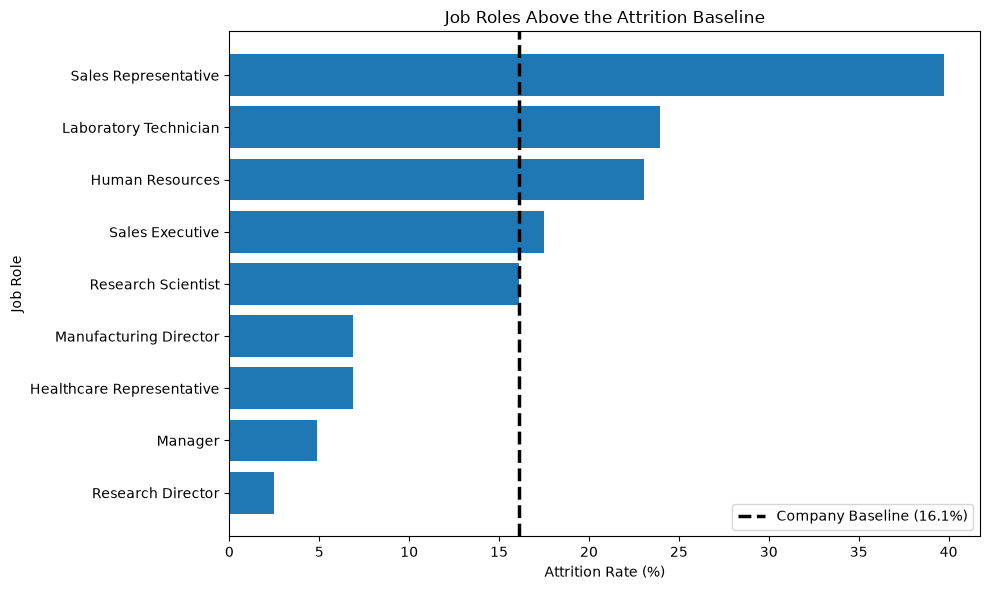

In [47]:
# Visualizing the JobRoles above the Attrition Rate Baseline (16.1%)
roles_above_baseline = (
    job_role_summary
    .sort_values("AttritionRate", ascending=True)
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    roles_above_baseline.index,
    roles_above_baseline["AttritionRate"]
)

# Company baseline
plt.axvline(
    BASELINE * 100,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Company Baseline ({BASELINE:.1%})"
)

plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.title("Job Roles Above the Attrition Baseline")

plt.legend()

plt.tight_layout()
plt.show()

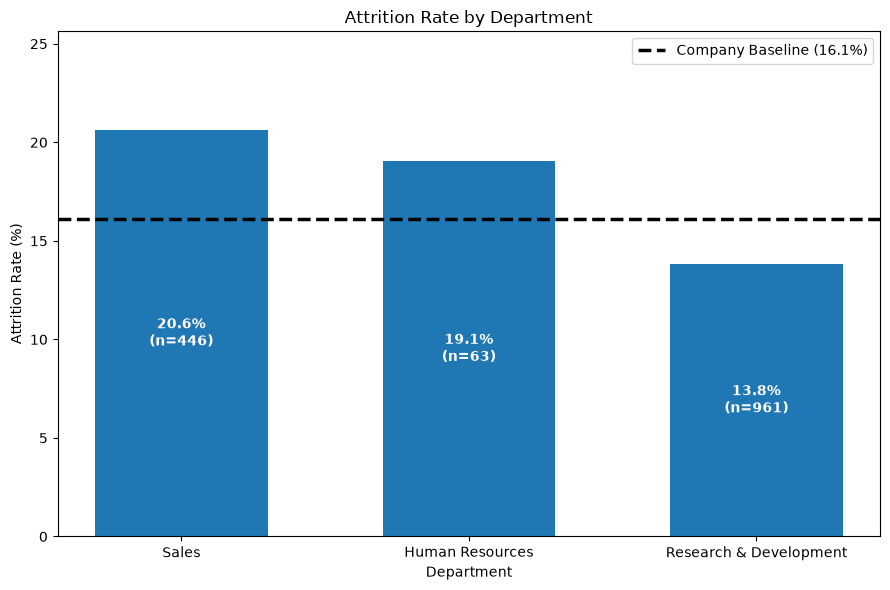

In [43]:
# Visualizing the Departments above the Attrition Rate Baseline (16.1%)
department_plot = department_summary.copy()

# Sort by attrition rate
department_plot = department_plot.sort_values(
    "AttritionRate",
    ascending=False
)

plt.figure(figsize=(9, 6))

# Bars
bars = plt.bar(
    department_plot.index,
    department_plot["AttritionRate"],
    width=0.6
)

# Company baseline
plt.axhline(
    BASELINE * 100,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Company Baseline ({BASELINE:.1%})"
)

# Labels inside bars
for bar, rate, headcount in zip(
    bars,
    department_plot["AttritionRate"],
    department_plot["Headcount"]
):
    if rate >= 8:
        # Place label inside the bar
        y = bar.get_height() / 2
        va = "center"
        text_color = "white"
    else:
        # Place label above very short bars
        y = bar.get_height() + 0.3
        va = "bottom"
        text_color = "black"

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f"{rate:.1f}%\n(n={headcount})",
        ha="center",
        va=va,
        fontweight="bold",
        color=text_color
    )

plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")
plt.title("Attrition Rate by Department")

plt.ylim(
    0,
    department_plot["AttritionRate"].max() + 5
)

plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# Before visualizing JobLevel that exceeded the baseline rate we'll categorize them
job_level_labels = {
    1: "1 - Entry",
    2: "2 - Junior",
    3: "3 - Intermediate",
    4: "4 - Senior",
    5: "5 - Leadership"
}

# Create a copy for visualization
job_level_plot = job_level_summary.copy()

# Replace numeric index with descriptive labels
job_level_plot.index = job_level_plot.index.map(job_level_labels)

# Define the desired order
job_level_order = [
    "1 - Entry",
    "2 - Junior",
    "3 - Intermediate",
    "4 - Senior",
    "5 - Leadership"
]

# Reorder the rows
job_level_plot = job_level_plot.reindex(job_level_order)

job_level_plot

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
JobLevel,,,,,
1 - Entry,543,143,26.34,10.22,1.63
2 - Junior,534,52,9.74,-6.38,0.60
3 - Intermediate,218,32,14.68,-1.44,0.91
4 - Senior,106,5,4.72,-11.40,0.29
5 - Leadership,69,5,7.25,-8.87,0.45


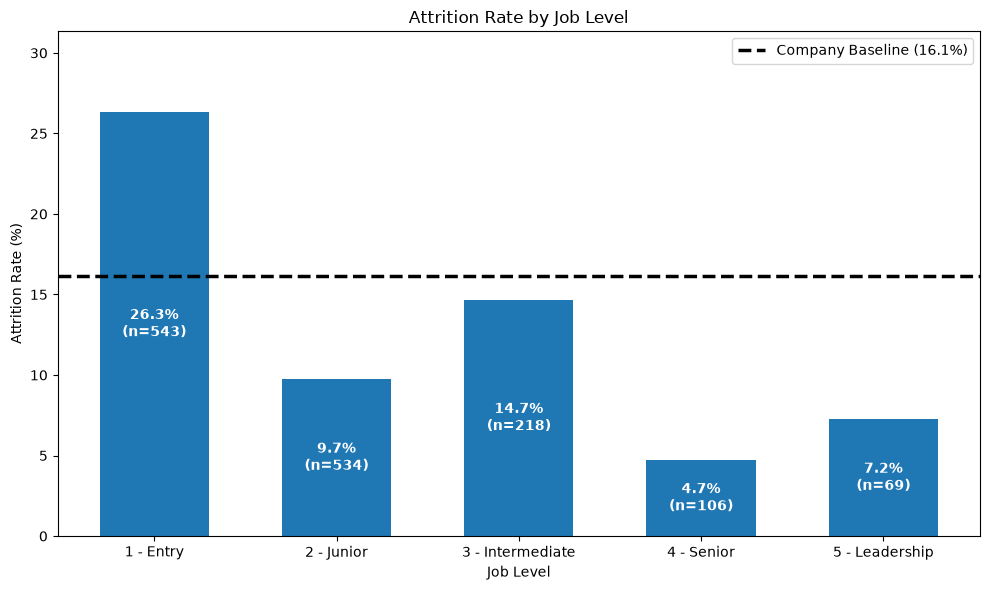

In [41]:
# Visualizing the JobLevel(s) above the Attrition Rate Baseline (16.1%)
plt.figure(figsize=(10, 6))

bars = plt.bar(
    job_level_plot.index,
    job_level_plot["AttritionRate"],
    width=0.6
)

# Company baseline
plt.axhline(
    BASELINE * 100,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Company Baseline ({BASELINE:.1%})"
)

# Labels inside bars
for bar, rate, headcount in zip(
    bars,
    job_level_plot["AttritionRate"],
    job_level_plot["Headcount"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{rate:.1f}%\n(n={headcount})",
        ha="center",
        va="center",
        fontweight="bold",
        color="white"
    )

plt.xlabel("Job Level")
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Job Level")

plt.ylim(
    0,
    max(job_level_plot["AttritionRate"]) + 5
)

plt.legend()
plt.tight_layout()
plt.show()